In [2]:
library(here)
library("misha")
library("misha.ext")
library("zoo")
library("tglkmeans")
library("misha.ext")
library("data.table")
library(tidyverse)
library(tgstat)
library(prego)
#gdb.reload()
options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)
link_dir = link_dir =  paste0(here(),'/')
setwd(here())
gsetroot(paste0(link_dir,'data/mm10/'))
gdb.reload()
source(paste0(link_dir,'code/seq2epi_utils.r'))
source(paste0(link_dir,'code/fig_fun.r'))



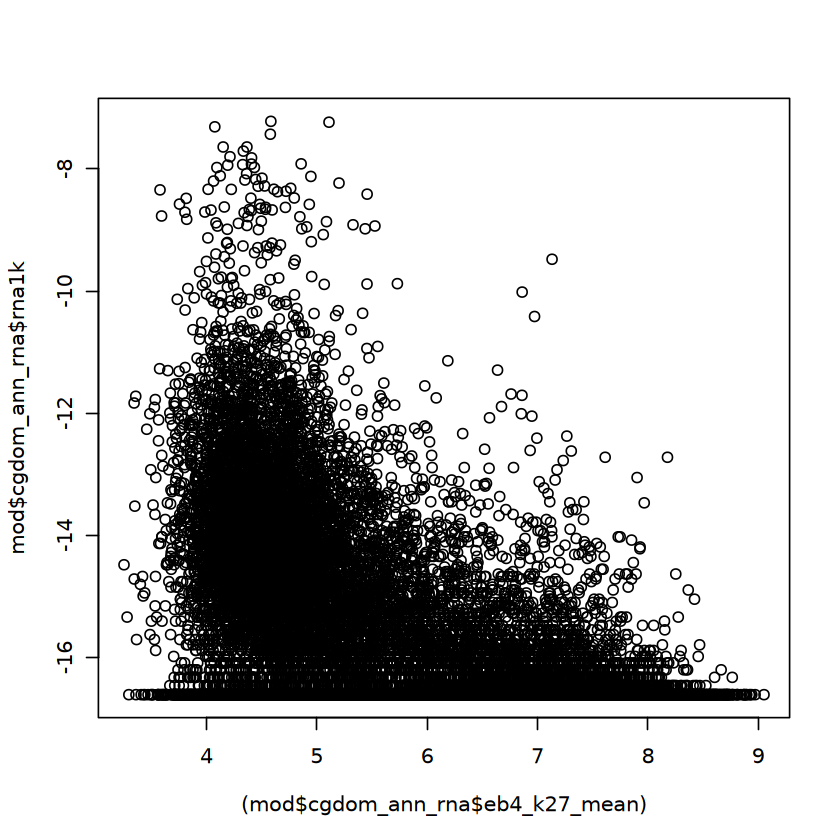

In [17]:
mod = init_pipe()
umis = readRDS("./data/files/L67_bulk_per_cond.rda")



umi_n = t(t(umis)/colSums(umis))

lumi = log2(1e-5+umi_n)

lumi = lumi %>% as.data.frame()%>%rownames_to_column()

mod$eb_legc_wt = lumi$wt_t_wt_d3

names(mod$eb_legc_wt) = lumi$rowname

mod = gen_regional_rna(mod)



mod$cgdom_ann_rna$rna1k[is.na(mod$cgdom_ann_rna$rna1k)] = min(mod$cgdom_ann_rna$rna1k,na.rm = T)

plot((mod$cgdom_ann_rna$eb4_k27_mean),mod$cgdom_ann_rna$rna1k)


 (-1,5]   (5,6]   (6,7] (7,7.5] (7.5,8] (8,9.5] 
   8127    4342    3208    1620    1405     746 

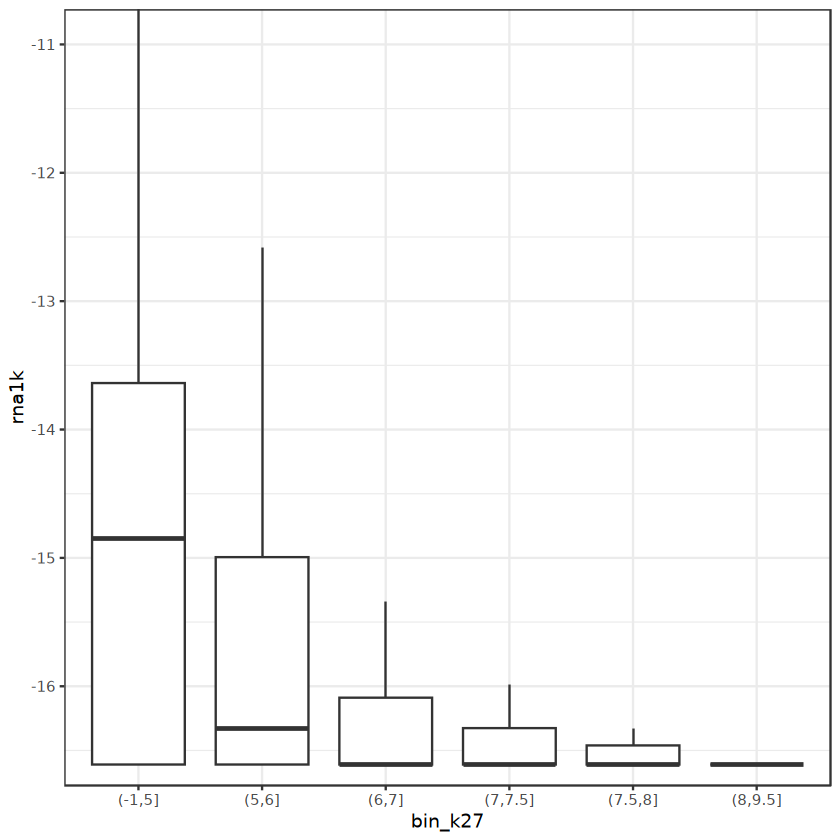

In [9]:
cgd = mod$cgdom_ann_rna

cgd$lk27 = mod$cgdom_ann_rna$eb4_k27_mean
cgd$bin_k27 = cut(cgd$lk27,c(-1,5,6,7,7.5,8,9.5))

table(cgd$bin_k27)

#new
plt = function(){
cgd %>% ggplot(aes(x = bin_k27, y = rna1k)) + geom_boxplot(outlier.shape = NA)+ theme_bw()+
coord_cartesian(ylim = c(-16.5,-11))
    }
save_baseR_to_ppt(plot_func = plot(1,1),link_ppt = './figs/rna_vs_pcg.pptx')
gg = plt()
print(gg)
save_gg_to_ppt(gg = gg,link = './figs/rna_vs_pcg.pptx')


  (-1,6.5]    (6.5,7]    (7,7.5] (7.5,7.75]   (7.75,8]      (8,9] 
      5622       2460       3640       3167       3426       1133 

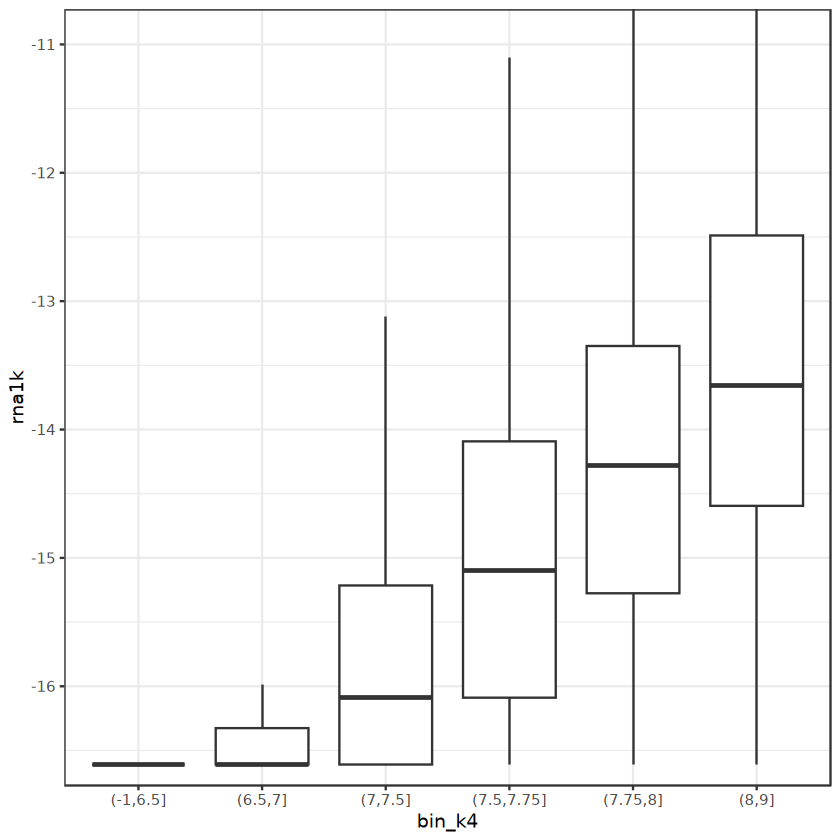

In [12]:
cgd$lk4 = log2(mod$cgdom_ann_rna$eb4_k4_max+1)
cgd$bin_k4 = cut(cgd$lk4,c(-1,6.5,7,7.5,7.75,8,9))#c(-1,3,4,5,6,7,7.5,9)

table(cgd$bin_k4)

cgd_k4 = cgd[ cgd$bin_k4!='(-1,5]' ,]


plt = function(){
cgd %>% ggplot(aes(x = bin_k4, y = rna1k)) + geom_boxplot(outlier.shape = NA)+ theme_bw()+
coord_cartesian(ylim = c(-16.5,-11))
    }
save_baseR_to_ppt(plot_func = plot(1,1),link_ppt = './figs/rna_vs_txg.pptx')
gg = plt()
print(gg)
save_gg_to_ppt(gg = gg,link = './figs/rna_vs_txg.pptx')

[1] 0.9505808

[1] 8512

[1] 0.947232

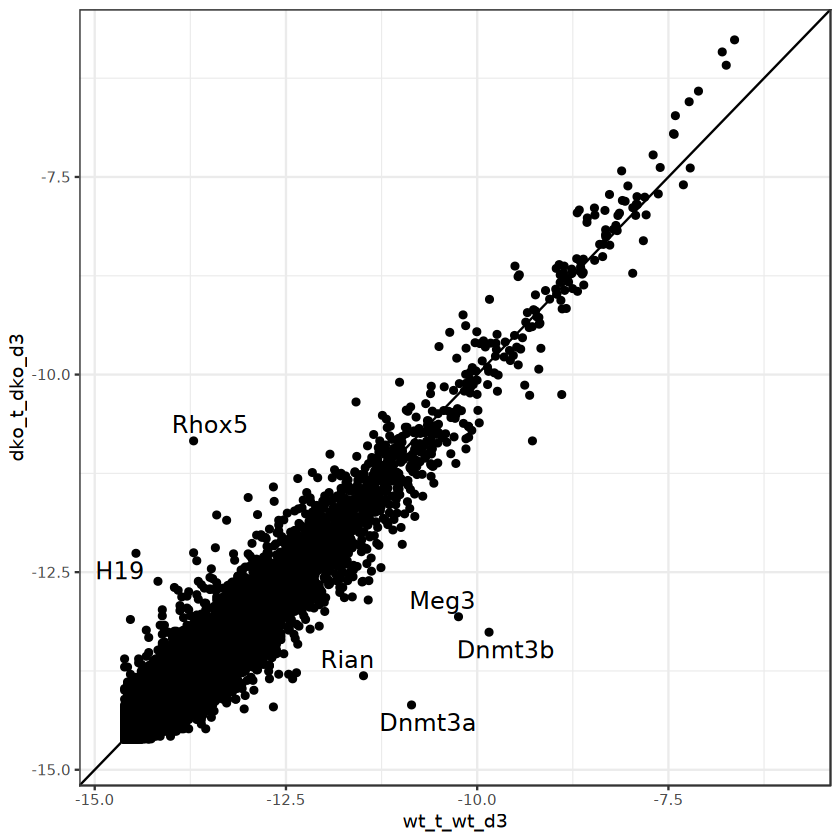

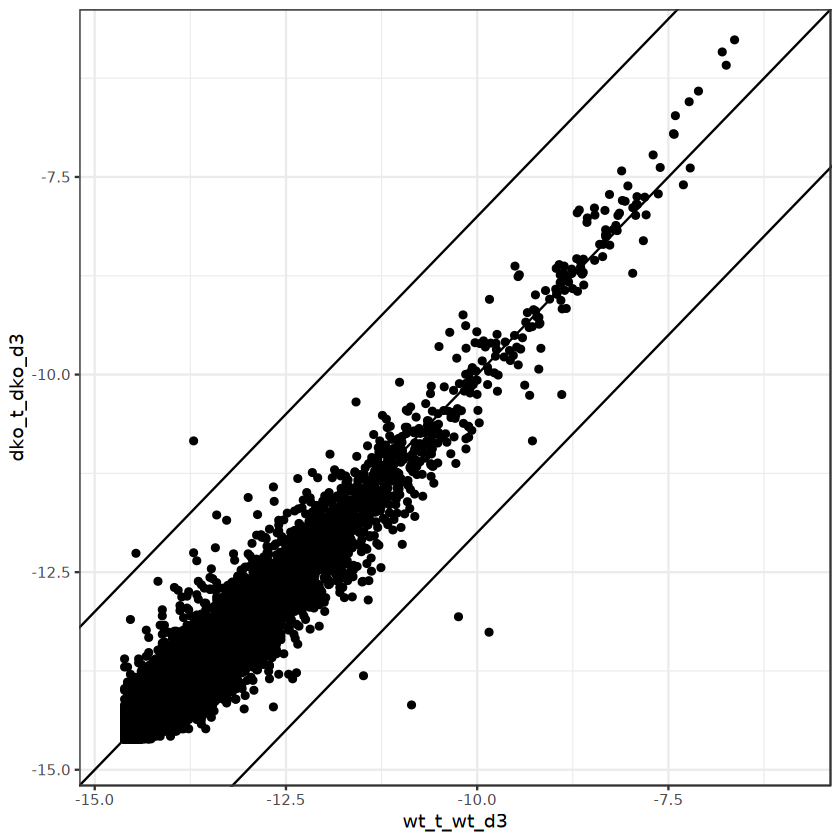

In [16]:
####dko

lumi = log2(4e-5+umi_n)
lumi = lumi %>% as.data.frame()%>%rownames_to_column()
up_wt = (lumi$wt_t_wt_d3 - lumi$dko_t_dko_d3) > 1
up_dko = (lumi$wt_t_wt_d3 - lumi$dko_t_dko_d3) < -1

cor(lumi$wt_t_wt_d3 , lumi$dko_t_dko_d3)^2

library(ggrepel)
lumi$col = abs(lumi$wt_t_wt_d3 - lumi$dko_t_dko_d3) > 2 
bad_gene_names = c(grep("^Gm[0-9]",lumi$rowname,v=T))
length(bad_gene_names)
f_bad = lumi$rowname %in% bad_gene_names
lumi_f = lumi[!f_bad,]

cor(lumi_f$wt_t_wt_d3 , lumi_f$dko_t_dko_d3,m='p')^2

xymin = min(c(lumi_f$wt_t_wt_d3,lumi_f$dko_t_dko_d3))*1.01
xymax = max(c(lumi_f$wt_t_wt_d3,lumi_f$dko_t_dko_d3))*1.01

lumi_f %>% ggplot(aes(x = wt_t_wt_d3,y = dko_t_dko_d3 )) + geom_point()+
geom_text_repel(data = filter(lumi_f, lumi_f$col),size=5,max.overlaps = 20,
                    aes(label=rowname))+geom_abline(slope = 1,intercept = 0)+
coord_cartesian(xlim = c(xymin,xymax),ylim = c(xymin,xymax))+ theme_bw()

lumi_f %>% ggplot(aes(x = wt_t_wt_d3,y = dko_t_dko_d3 )) + geom_point()+
geom_abline(slope = 1,intercept = 0)+
geom_abline(slope = 1,intercept = 2)+
geom_abline(slope = 1,intercept = -2)+
coord_cartesian(xlim = c(xymin,xymax),ylim = c(xymin,xymax))+ theme_bw()